## 1. Setup and Imports

In [2]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), 'code'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc

from model.neural_network import create_model
from train.data_preprocessing import DataPreprocessor
from train.trainer import Trainer

# Set random seeds
np.random.seed(1)
torch.manual_seed(1)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

Libraries imported successfully!
PyTorch version: 2.8.0
Device: CPU


## 2. Data Loading and Exploration

In [3]:
# File paths
train_data_path = 'traindata.csv'
train_label_path = 'trainlabel.txt'
test_data_path = 'testdata.csv'

# Load data
preprocessor = DataPreprocessor()
train_df, train_labels, test_df = preprocessor.load_data(
    train_data_path, train_label_path, test_data_path
)

print(f"Training data shape: {train_df.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test data shape: {test_df.shape}")

Training data shape: (22792, 14)
Training labels shape: (22792,)
Test data shape: (9769, 14)


In [3]:
# Display first few rows
print("\nFirst 5 rows of training data:")
train_df.head()


First 5 rows of training data:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,77,Local-gov,177550,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,3818,0,14,United-States
1,40,Self-emp-inc,475322,Bachelors,13,Separated,Craft-repair,Own-child,White,Male,0,0,50,United-States
2,29,Self-emp-not-inc,341672,HS-grad,9,Married-spouse-absent,Transport-moving,Other-relative,Asian-Pac-Islander,Male,0,1564,50,India
3,41,Private,184378,HS-grad,9,Separated,Craft-repair,Not-in-family,White,Male,0,0,40,United-States
4,22,Private,306967,Some-college,10,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,25,United-States


In [4]:
# Basic statistics
print("Dataset Information:")
print(f"Number of features: {train_df.shape[1]}")
print(f"\nFeature names: {list(train_df.columns)}")
print(f"\nData types:")
train_df.dtypes

Dataset Information:
Number of features: 14

Feature names: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']

Data types:


age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
dtype: object

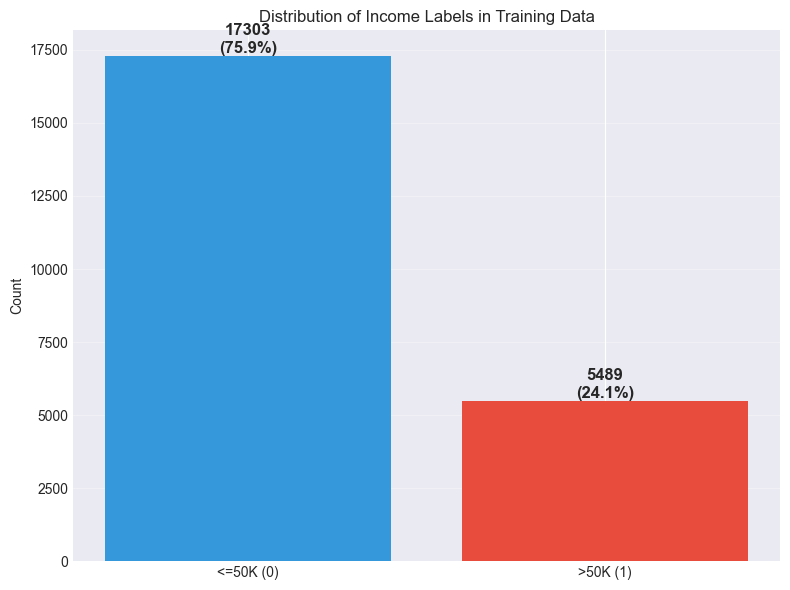

Class distribution:
  <=50K (0): 17303 (75.92%)
  >50K (1): 5489 (24.08%)


In [5]:
# Label distribution
unique, counts = np.unique(train_labels, return_counts=True)
label_dist = dict(zip(unique, counts))

plt.figure(figsize=(8, 6))
plt.bar(['<=50K (0)', '>50K (1)'], [label_dist[0], label_dist[1]], color=['#3498db', '#e74c3c'])
plt.ylabel('Count')
plt.title('Distribution of Income Labels in Training Data')
plt.grid(axis='y', alpha=0.3)
for i, (label, count) in enumerate(label_dist.items()):
    plt.text(i, count, f'{count}\n({count/sum(counts)*100:.1f}%)', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Class distribution:")
print(f"  <=50K (0): {label_dist[0]} ({label_dist[0]/sum(counts)*100:.2f}%)")
print(f"  >50K (1): {label_dist[1]} ({label_dist[1]/sum(counts)*100:.2f}%)")

In [9]:
# Check for missing values
missing_train = train_df.isna().sum()
missing_test = test_df.isna().sum()

# Check for ' ?' values
question_train = (train_df == '?').sum()
question_test = (test_df == '?').sum()

print("Missing values (NaN) in training data:")
print(missing_train[missing_train > 0])
print("\n' ?' values in training data:")
print(question_train[question_train > 0])

Missing values (NaN) in training data:
Series([], dtype: int64)

' ?' values in training data:
workclass         1278
occupation        1283
native.country     423
dtype: int64

填充后train中各列缺失值数量：
Series([], dtype: int64)

填充后test中各列缺失值数量：
Series([], dtype: int64)


/var/folders/8b/5bjpg7j513b1js7j93x8_6g40000gn/T/ipykernel_25592/949487289.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(mode, inplace=True)
/var/folders/8b/5bjpg7j513b1js7j93x8_6g40000gn/T/ipykernel_25592/949487289.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

## 3. Data Preprocessing

In [6]:
# Preprocess data with downsampling to balance classes
print("Preprocessing data with downsampling...")
X_train_scaled, y_train, X_test_scaled, feature_names = preprocessor.preprocess(
    train_df, train_labels, test_df,
    apply_downsampling=True,  # Enable downsampling to balance classes
    random_state=1
)

print(f"\nPreprocessed training data shape (after downsampling): {X_train_scaled.shape}")
print(f"Preprocessed test data shape: {X_test_scaled.shape}")
print(f"Number of features after preprocessing: {len(feature_names)}")

# Verify class balance after downsampling
unique, counts = np.unique(y_train, return_counts=True)
print(f"\nClass distribution after downsampling:")
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count} ({count/len(y_train)*100:.2f}%)")

Preprocessing data with downsampling...

Preprocessed training data shape (after downsampling): (10978, 14)
Preprocessed test data shape: (9769, 14)
Number of features after preprocessing: 14

Class distribution after downsampling:
  Class 0: 5489 (50.00%)
  Class 1: 5489 (50.00%)


In [7]:
# Split training data
X_train, X_val, y_train_split, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test_scaled.shape[0]}")

Training set size: 8782
Validation set size: 2196
Test set size: 9769


## 4. Model Architecture

In [8]:
# Create model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
input_dim = X_train.shape[1]

model = create_model(
    input_dim=input_dim,
    hidden_dims=[128, 64, 32]
)

print("Neural Network Architecture:")
print("="*50)
print(model)
print("="*50)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Neural Network Architecture:
NeuralNetwork(
  (model): Sequential(
    (0): Linear(in_features=14, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=2, bias=True)
    (7): Softmax(dim=1)
  )
)

Total parameters: 12,322
Trainable parameters: 12,322


## 5. Model Training

In [9]:
# Create trainer
trainer = Trainer(model, device=device, learning_rate=0.00001)

# Train model
print("Training the model...")
history = trainer.fit(
    X_train, y_train_split,
    X_val, y_val,
    epochs=500,
    batch_size=128,
    verbose=True
)

print("\nTraining completed!")

Training the model...
Epoch [5/500], Train Loss: 0.6854, Train Acc: 0.6889, Val Loss: 0.6840, Val Acc: 0.7090
Epoch [10/500], Train Loss: 0.6749, Train Acc: 0.7490, Val Loss: 0.6731, Val Acc: 0.7582
Epoch [15/500], Train Loss: 0.6588, Train Acc: 0.7450, Val Loss: 0.6568, Val Acc: 0.7495
Epoch [20/500], Train Loss: 0.6370, Train Acc: 0.7452, Val Loss: 0.6352, Val Acc: 0.7541
Epoch [25/500], Train Loss: 0.6132, Train Acc: 0.7519, Val Loss: 0.6125, Val Acc: 0.7618
Epoch [30/500], Train Loss: 0.5918, Train Acc: 0.7569, Val Loss: 0.5925, Val Acc: 0.7664
Epoch [35/500], Train Loss: 0.5750, Train Acc: 0.7637, Val Loss: 0.5766, Val Acc: 0.7687
Epoch [40/500], Train Loss: 0.5617, Train Acc: 0.7646, Val Loss: 0.5642, Val Acc: 0.7709
Epoch [45/500], Train Loss: 0.5513, Train Acc: 0.7680, Val Loss: 0.5543, Val Acc: 0.7760
Epoch [50/500], Train Loss: 0.5434, Train Acc: 0.7711, Val Loss: 0.5467, Val Acc: 0.7796
Epoch [55/500], Train Loss: 0.5374, Train Acc: 0.7743, Val Loss: 0.5408, Val Acc: 0.7823


## 6. Training Results Visualization

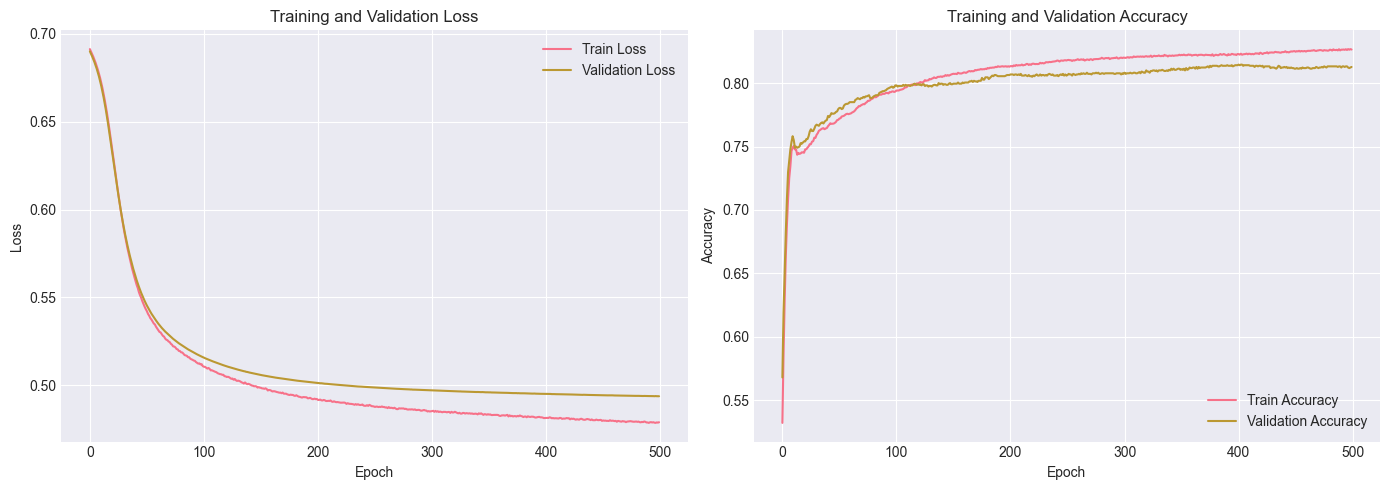

In [10]:
# Plot training history
os.makedirs('figures', exist_ok=True)
trainer.plot_training_history(save_path='figures/training_history.png')
plt.show()

## 7. Model Evaluation

In [11]:
# Evaluate on validation set
metrics, val_predictions = trainer.evaluate(X_val, y_val)

print("Validation Set Metrics:")
print("="*50)
for metric_name, value in metrics.items():
    print(f"{metric_name.capitalize():20s}: {value:.4f}")
print("="*50)

Validation Set Metrics:
Accuracy            : 0.8128
Precision           : 0.7879
Recall              : 0.8561
F1_score            : 0.8206
Roc_auc             : 0.8959


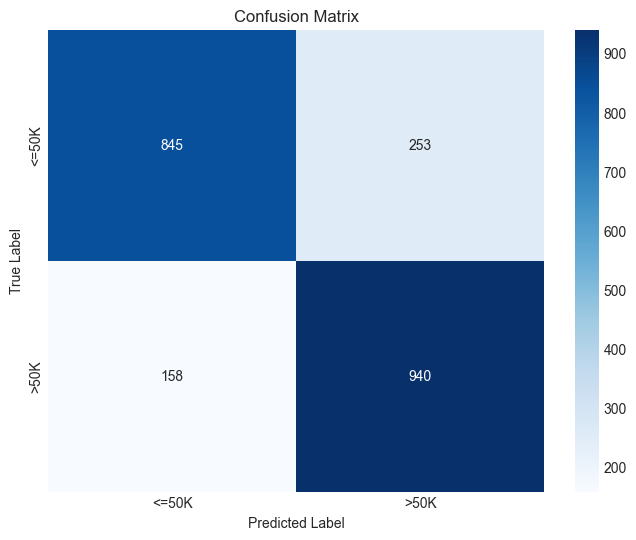

In [12]:
# Confusion Matrix
trainer.plot_confusion_matrix(y_val, val_predictions, save_path='figures/confusion_matrix.png')
plt.show()

In [13]:
# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_val, val_predictions, 
                          target_names=['<=50K', '>50K'],
                          digits=4))


Detailed Classification Report:
              precision    recall  f1-score   support

       <=50K     0.8425    0.7696    0.8044      1098
        >50K     0.7879    0.8561    0.8206      1098

    accuracy                         0.8128      2196
   macro avg     0.8152    0.8128    0.8125      2196
weighted avg     0.8152    0.8128    0.8125      2196



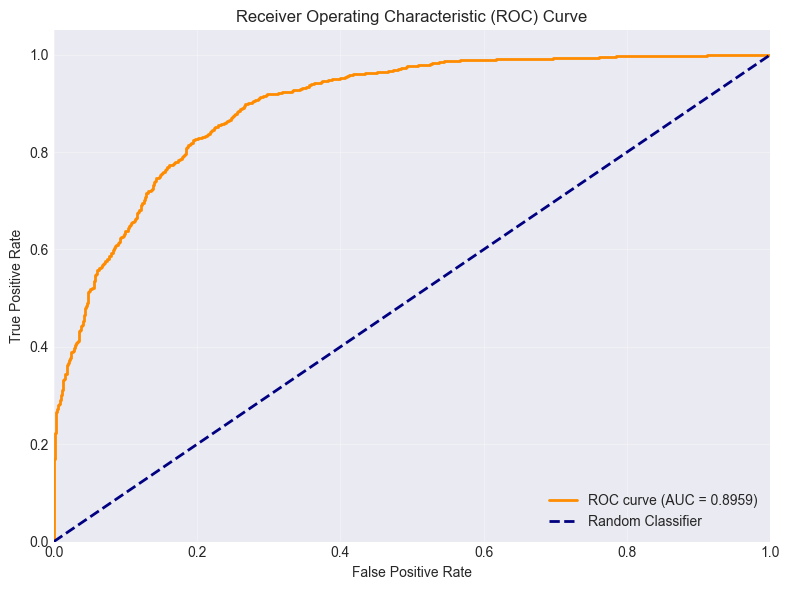

In [14]:
# ROC Curve
val_probabilities = trainer.predict_proba(X_val)
fpr, tpr, thresholds = roc_curve(y_val, val_probabilities)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Test Set Predictions

In [15]:
# Make predictions on test set
test_predictions = trainer.predict(X_test_scaled)

print(f"Test set predictions generated: {len(test_predictions)} samples")

# Prediction distribution
unique, counts = np.unique(test_predictions, return_counts=True)
print("\nTest Set Prediction Distribution:")
for label, count in zip(unique, counts):
    class_name = '<=50K' if label == 0 else '>50K'
    print(f"  {class_name} ({label}): {count} ({count/len(test_predictions)*100:.2f}%)")

Test set predictions generated: 9769 samples

Test Set Prediction Distribution:
  <=50K (0): 6075 (62.19%)
  >50K (1): 3694 (37.81%)


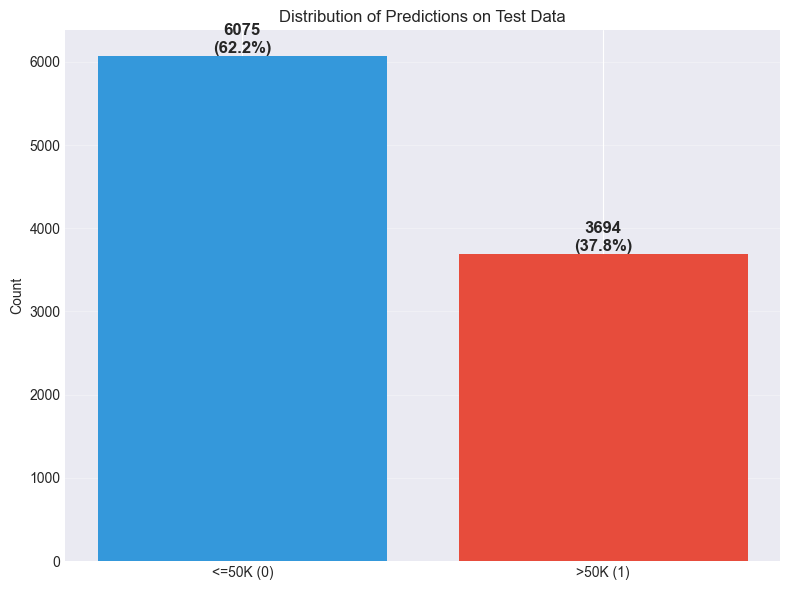

In [16]:
# Visualize test predictions
plt.figure(figsize=(8, 6))
plt.bar(['<=50K (0)', '>50K (1)'], counts, color=['#3498db', '#e74c3c'])
plt.ylabel('Count')
plt.title('Distribution of Predictions on Test Data')
plt.grid(axis='y', alpha=0.3)
for i, count in enumerate(counts):
    plt.text(i, count, f'{count}\n({count/len(test_predictions)*100:.1f}%)', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/test_predictions_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Save Predictions

In [17]:
# Save predictions to file
output_path = 'testlabel.txt'
with open(output_path, 'w') as f:
    for pred in test_predictions:
        f.write(f"{pred}\n")

print(f"✓ Predictions saved to: {output_path}")

✓ Predictions saved to: testlabel.txt
